In [1]:
# In[1] — thread caps (fork-safety / reproducibility)
import os
for v in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS',
          'VECLIB_MAXIMUM_THREADS','NUMEXPR_NUM_THREADS'):
    os.environ[v] = '1'

In [2]:
# In[2] — imports, path, reload, confirm the passthrough is in your repo
import sys, os, importlib, warnings, inspect
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

In [3]:
import warnings, time as _t, os
import numpy as np, xarray as xr, seasonal_scan_harness as ssh
from xso.parscans import run_parallel_tasks
from baseline_r0_seasonal_comps import _build_fourier_func
# --- era anchors (obs-derived, construct-independent) ---
forc_obs = ssh.build_forcings(['pre+recovery','post'])
def _smooth(m,n=2): return _build_fourier_func(m,period=365.0,n_harmonics=n)(np.linspace(0,365,365))
def _char(m):
    s=_smooth(m); return float(s.mean()), float((s.max()-s.min())/2), int(np.argmax(s))
POST_FN_M,POST_FN_A,POST_FN_PHI=_char(forc_obs['post']['fn']); PRE_FN_M,PRE_FN_A,_=_char(forc_obs['pre+recovery']['fn'])
POST_DE_M,POST_DE_A,_=_char(forc_obs['post']['de']); PRE_DE_M,PRE_DE_A,_=_char(forc_obs['pre+recovery']['de'])
POST_T_M,POST_T_A,_=_char(forc_obs['post']['t']);    PRE_T_M,PRE_T_A,_=_char(forc_obs['pre+recovery']['t'])
PHI=POST_FN_PHI; MID_DOY=np.array([15,46,74,105,135,166,196,227,258,288,319,349])
def sinusoidal_monthly(alpha):
    fn_m=POST_FN_M+alpha*(PRE_FN_M-POST_FN_M); fn_a=POST_FN_A+alpha*(PRE_FN_A-POST_FN_A)
    de_m=POST_DE_M+alpha*(PRE_DE_M-POST_DE_M); de_a=POST_DE_A+alpha*(PRE_DE_A-POST_DE_A)
    t_m =POST_T_M +alpha*(PRE_T_M -POST_T_M);  t_a =POST_T_A +alpha*(PRE_T_A -POST_T_A)
    c=np.cos(2*np.pi*(MID_DOY-PHI)/365)
    return {'fn':np.maximum(fn_m+fn_a*c,0.01),'de':np.maximum(de_m-de_a*c,5.0),'t':t_m-t_a*c}
# --- scan axes ---
ALPHAS=np.linspace(-0.5,2.0,50); R_F=np.linspace(0.0,0.6,50)
print(f"tasks: {len(ALPHAS)*len(R_F)} | solver: {ssh.SEASONAL_SOLVER_KWARGS}")
# --- construct A (frozen, routed) ---
spec=ssh.allometry('maranon_ward')
GRZ={'KsZ':0.15,'sigma_log':0.20}
IVO={'GrazingRouter':{'gge':0.25},'FishGrazing':{'frac_D':0.25,'frac_export':0.25},
     'DetritusSink':{'w_sink':5.0},'DetritusRemin':{'k_remin':0.067},
     'ZooQuadMortality':{'frac_D':0.90,'frac_export':0.0},'ZooLinMortality':{'frac_D':0.90,'frac_export':0.0}}
combos=[(a,rf) for a in ALPHAS for rf in R_F]
tasks=[(dict(construct=spec, forcing=sinusoidal_monthly(a), fish_rate=float(rf), years=60, spinup=15,
             mP=0.0015, m_Z=0.10, grazing=GRZ, iv_overrides=IVO,
             n_harmonics=3, routed=True, return_traj=True),) for a,rf in combos]
# --- containers ---
shape=(len(ALPHAS),len(R_F))
def _empty(*d): return np.full((*shape,*d),np.nan)
SCALAR_FIELDS=['mcs','mcs_med','pico','nano','micro','sumP','sumZ','Z200','Z500','Z200_peak','N','PP','Export',
               'cv_sumP','cv_sumZ','mcs_conv','minP','minZ','nan_frac','squiggle_sumP','squiggle_micro']
CLIM_FIELDS=['mcs','pico','nano','micro','sumP','Z200','Z500','N','PP']
TRAJ_MAP=[('mcs','mcs'),('pico','pico'),('nano','nano'),('micro','micro'),('sumP','sumP'),('Ztot','sumZ'),
          ('Z200','Z200'),('Z500','Z500'),('N','N'),('PP','PP')]
TAIL_DAYS=1000
scalars={k:_empty() for k in SCALAR_FIELDS}; clims={k:_empty(12) for k in CLIM_FIELDS}
trajs={dn:_empty(TAIL_DAYS) for _,dn in TRAJ_MAP}; HASN=np.zeros(shape,dtype=bool)
def on_result(item,done,n):
    k=item['index']; i,j=divmod(k,len(R_F))
    if not item['ok']: return
    clim,r=item['result']; HASN[i,j]=bool(clim.get('has_nan',False))
    for f in SCALAR_FIELDS: scalars[f][i,j]=clim.get(f,np.nan)
    for f in CLIM_FIELDS:
        v=clim.get('clim_'+f)
        if v is not None and len(v)==12: clims[f][i,j,:]=v
    if not HASN[i,j] and 't' in r and len(r['t'])>=TAIL_DAYS:
        for rk,dn in TRAJ_MAP:
            if rk in r:
                v=np.asarray(r[rk])
                if len(v)==len(r['t']): trajs[dn][i,j,:]=v[-TAIL_DAYS:]
t0=_t.perf_counter()
run_parallel_tasks(ssh._seasonal_worker, tasks, processes=None, on_result=on_result,
                   tally_flags=['has_nan'], label='fig5_A_50x50', maxtasksperchild=1)
print(f"wall {(_t.perf_counter()-t0)/60:.1f} min | trips {int(HASN.sum())}/{HASN.size}")
# --- save ---
os.makedirs('results',exist_ok=True); nc='results/fig5_alpha_sinusoidal_50x50_A_2026-06-29.nc'
ds=xr.Dataset(
    data_vars={**{k:(('alpha','rF'),scalars[k]) for k in SCALAR_FIELDS},
               **{f'clim_{k}':(('alpha','rF','month'),clims[k]) for k in CLIM_FIELDS},
               **{f'traj_{k}':(('alpha','rF','day'),trajs[k]) for _,k in TRAJ_MAP},
               'has_nan':(('alpha','rF'),HASN.astype(np.int8))},
    coords={'alpha':ALPHAS,'rF':R_F,'month':np.arange(1,13),'day':np.arange(TAIL_DAYS)},
    attrs=dict(construct='A: maranon_ward + Dutkiewicz Type III, ROUTED',
               KsZ=0.15, GGE=0.25, sigma_log=0.20, m_Z=0.10, mP=0.0015, w_sink=5.0, k_remin=0.067,
               fish_routing='N0.50/D0.25/export0.25', zoo_routing='0.10N/0.90D', n_harmonics=3,
               forcing='idealised sinusoidal, anti-phase locked, post(α0)↔pre+rec(α1)',
               era_markers='post (α=0, r_F=0.10); pre+rec (α=1, r_F=0.55)',
               years=60, spinup=15, tail_days=TAIL_DAYS, created='2026-06-29',
               solver='tight RK45; maxtasksperchild=1 (scipy#10070)'))
ds.to_netcdf(nc); print(f"saved {nc} ({os.path.getsize(nc)/1e6:.1f} MB)")

tasks: 2500 | solver: {'method': 'RK45', 'atol': 1e-09, 'rtol': 1e-06, 'max_step': 1.0, 'instability_neg_threshold': -0.001}
--- run_parallel_tasks: 2500 tasks, 19 workers (fig5_A_50x50) ---
     1/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.2m ETA 3092.1m
     2/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.2m ETA 1556.1m
     3/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.2m ETA 1037.1m
     4/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.2m ETA 778.2m
     5/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 624.4m
     6/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 520.3m
     7/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 447.5m
     8/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 392.4m
     9/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 348.9m
    10/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 314.4m
    11/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 288.4m
    12/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 264.3m
    13/2500 fig5_A_50x50 | err=0 has_nan=0 | 1.3m ETA 246.1m
    14/2500 f

/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=7478 on Z[5] = -0.00164. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  2003/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.1m ETA 129.8m
  2004/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.1m ETA 129.5m
  2005/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.1m ETA 129.2m
  2006/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.2m ETA 128.8m
  2007/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.2m ETA 128.5m
  2008/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.3m ETA 128.2m
  2009/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.4m ETA 127.9m
  2010/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.4m ETA 127.6m
  2011/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.5m ETA 127.3m
  2012/2500 fig5_A_50x50 | err=0 has_nan=0 | 523.5m ETA 127.0m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.169e+04 on Z[0] = -0.00101. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  2013/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.1m ETA 126.8m
  2014/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.2m ETA 126.5m
  2015/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.3m ETA 126.2m
  2016/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.3m ETA 125.9m
  2017/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.5m ETA 125.6m
  2018/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.6m ETA 125.3m
  2019/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.8m ETA 125.0m
  2020/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.8m ETA 124.7m
  2021/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.8m ETA 124.4m
  2022/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.9m ETA 124.1m
  2023/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.9m ETA 123.8m
  2024/2500 fig5_A_50x50 | err=0 has_nan=0 | 524.9m ETA 123.5m
  2025/2500 fig5_A_50x50 | err=0 has_nan=0 | 525.0m ETA 123.2m
  2026/2500 fig5_A_50x50 | err=0 has_nan=0 | 525.1m ETA 122.8m
  2027/2500 fig5_A_50x50 | err=0 has_nan=0 | 525.2m ETA 122.5m
  2028/2500 fig5_A_50x50 | err=0 has_nan=0 | 525.2m ETA

...

  2482/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.6m ETA 4.1m
  2483/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.7m ETA 3.9m
  2484/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.8m ETA 3.6m
  2485/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.8m ETA 3.4m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=1.016e+04 on Z[4] = -0.00183. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  2486/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.8m ETA 3.2m
  2487/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.8m ETA 3.0m
  2488/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.9m ETA 2.7m
  2489/2500 fig5_A_50x50 | err=0 has_nan=0 | 565.9m ETA 2.5m
  2490/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.1m ETA 2.3m
  2491/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.2m ETA 2.0m
  2492/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.2m ETA 1.8m
  2493/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.2m ETA 1.6m


/Users/aoop/Documents/GitHub/xarray-simlab-ode/src/xso/core.py:148: UserWarning: Instability event triggered at t=2.03e+04 on P[15] = -0.00112. Run terminated, remaining time points NaN-padded. To loosen the safety threshold pass solver_kwargs={'instability_neg_threshold': -1e-3} to xso.setup; to disable, pass float('-inf').
  self.solver.solve(self.model, time_step)


  2494/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.4m ETA 1.4m
  2495/2500 fig5_A_50x50 | err=0 has_nan=0 | 566.7m ETA 1.1m
  2496/2500 fig5_A_50x50 | err=0 has_nan=0 | 567.0m ETA 0.9m
  2497/2500 fig5_A_50x50 | err=0 has_nan=0 | 567.0m ETA 0.7m
  2498/2500 fig5_A_50x50 | err=0 has_nan=0 | 567.1m ETA 0.5m
  2499/2500 fig5_A_50x50 | err=0 has_nan=0 | 567.1m ETA 0.2m
  2500/2500 fig5_A_50x50 | err=0 has_nan=0 | 567.2m ETA 0.0m
--- fig5_A_50x50 done: 2500/2500 ok, 0 errored, has_nan=0 | 567.2m ---
wall 232.6 min | trips 22/2500
saved results/fig5_alpha_sinusoidal_50x50_A_2026-06-29.nc (202.6 MB)


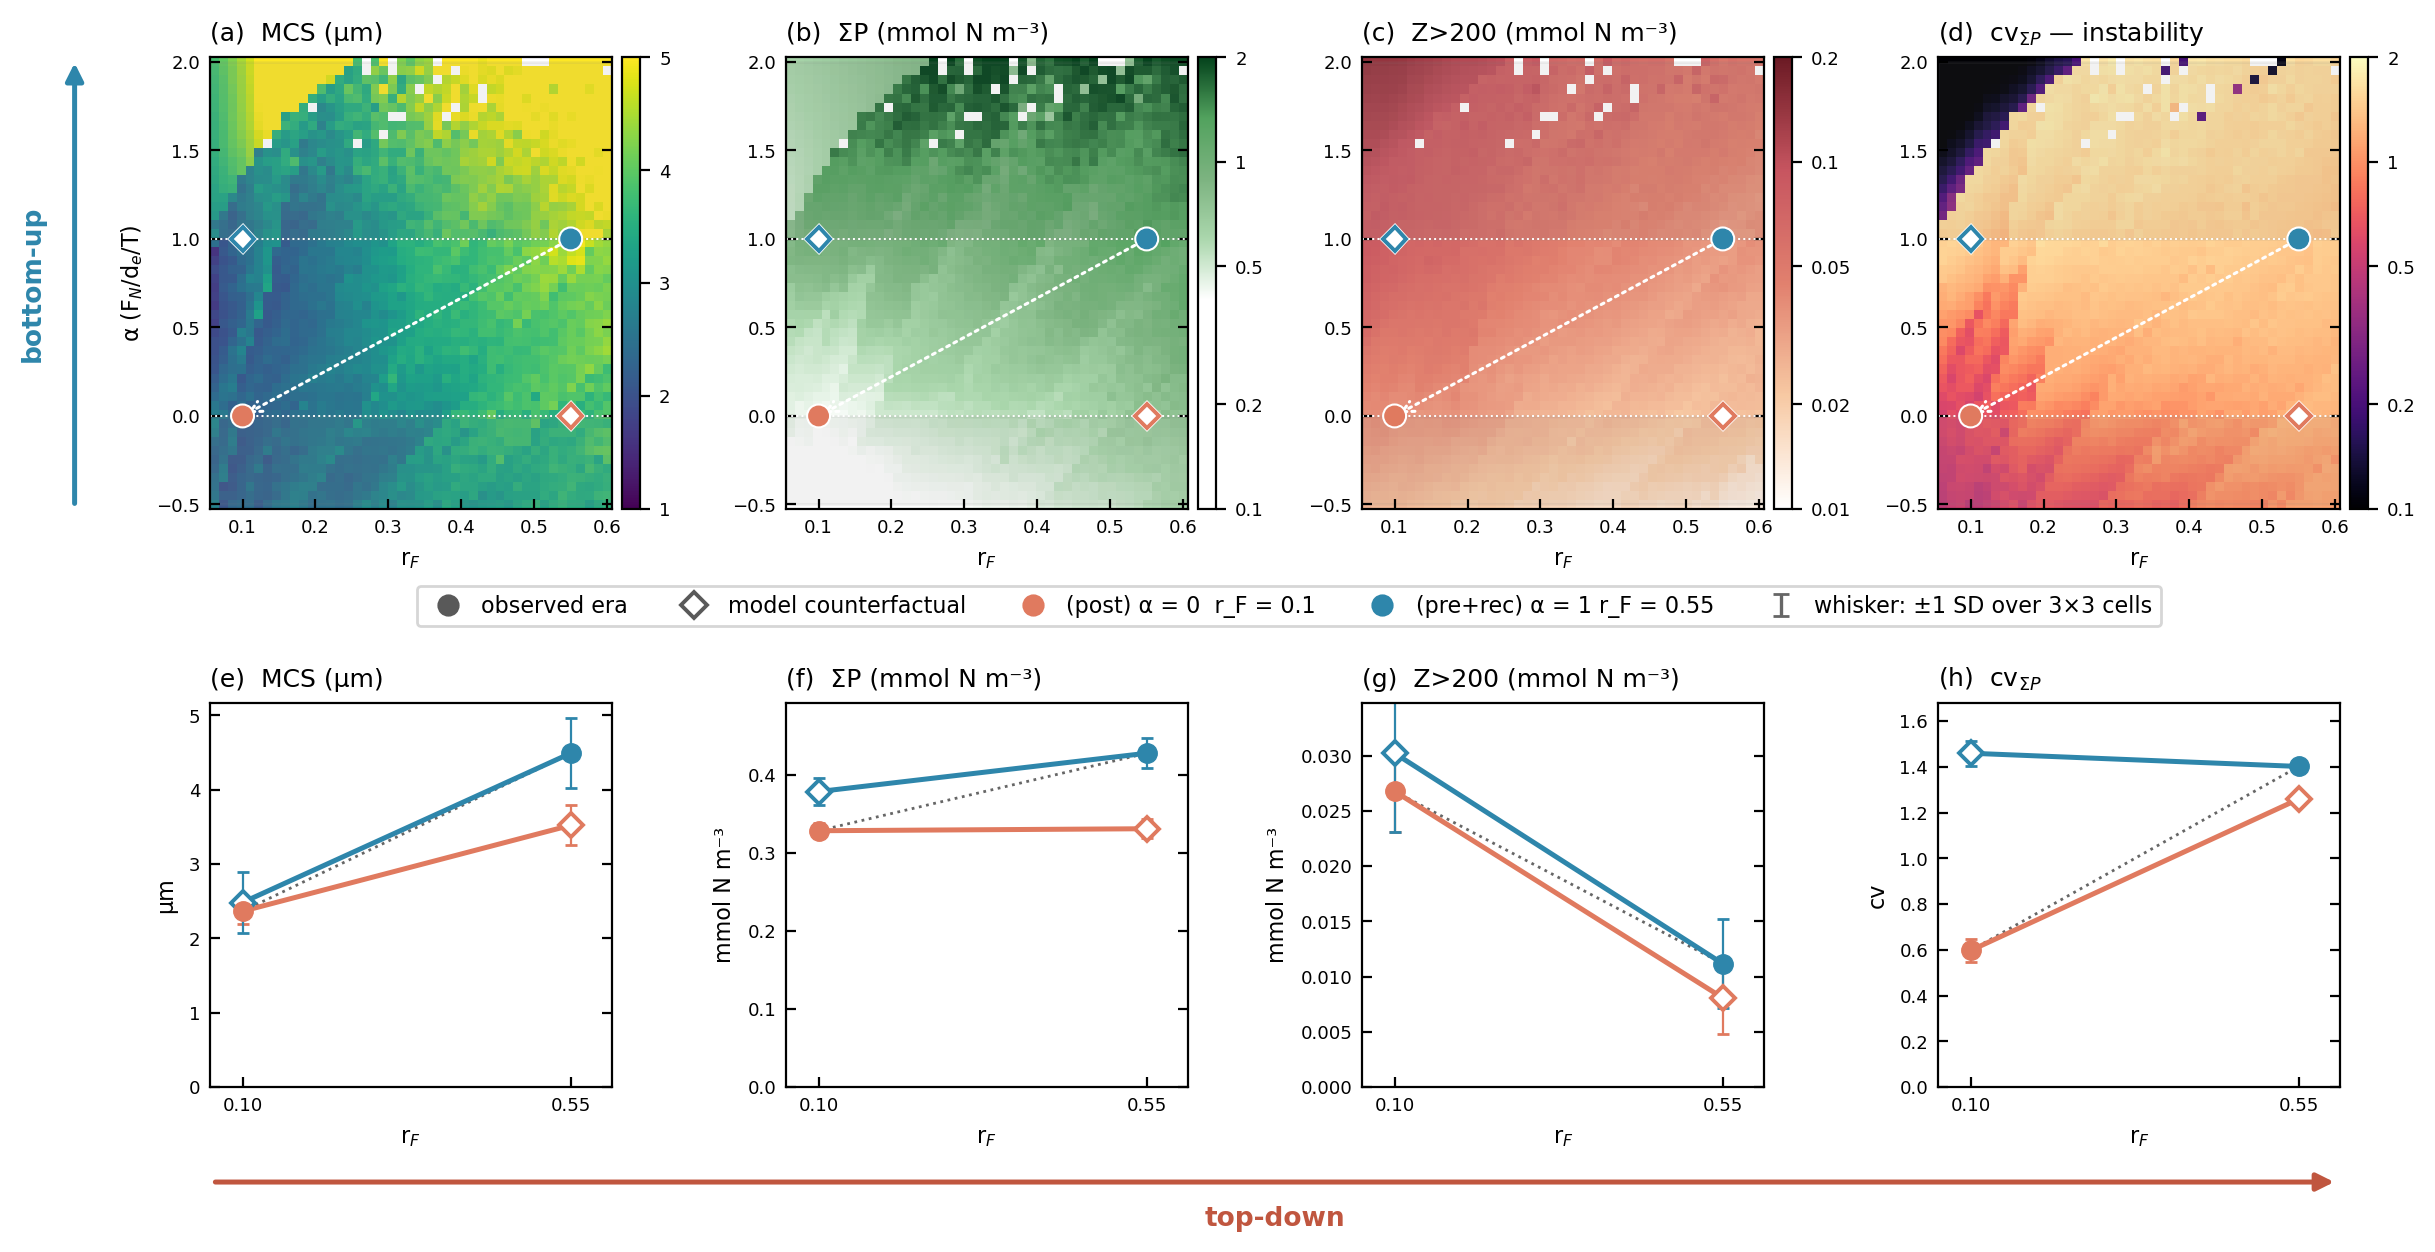

In [4]:
%config InlineBackend.figure_format = 'retina'
import numpy as np, matplotlib.pyplot as plt, xarray as xr
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm, Normalize, LinearSegmentedColormap
from matplotlib.ticker import NullLocator
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.axes_grid1 import make_axes_locatable

ds = xr.open_dataset('results/fig5_alpha_sinusoidal_50x50_A_2026-06-29.nc')   # ← A
A_NAME, R_NAME, D_NAME = 'alpha', 'rF', 'day'
RF_MIN = 0.05; A0, A1, RL, RH = 0.0, 1.0, 0.1, 0.55; W = 1                     # ← A: RH 0.5→0.55
C_POST, C_PRE = '#E07A5F', '#2E86AB'
BU_COL, TD_COL = '#2E86AB', '#C0563F'                 # framing arrows: blue = bottom-up, red = top-down
HALO = [pe.withStroke(linewidth=2.0, foreground='white')]
cmap_phiP = LinearSegmentedColormap.from_list('phiP', ['white','#ABD7AD','#7CB380','#52A25E','#04421C'])
cmap_phiZ = LinearSegmentedColormap.from_list('phiZ', ['white','#F7C9A3','#E1806E','#C75560','#6B1A24'])
def style(ax): ax.tick_params(top=False, right=True, direction='in', labelsize=6.5)

dsf = ds.sel({R_NAME: slice(RF_MIN, None)})
alpha, R_F = dsf[A_NAME].values, dsf[R_NAME].values
av, rv = ds[A_NAME].values, ds[R_NAME].values
dr = R_F[1] - R_F[0]; XLIM = (R_F[0] - dr/2, R_F[-1] + dr/2)
def surf(k): return dsf[k].transpose(A_NAME, R_NAME).values
def corner(key, a, rf, mode):
    i = int(np.argmin(np.abs(av-a))); j = int(np.argmin(np.abs(rv-rf)))
    blk = ds[key].isel({A_NAME: slice(max(i-W,0),i+W+1), R_NAME: slice(max(j-W,0),j+W+1)})
    vals = (blk.median(D_NAME) if mode == 'traj' else blk).values
    return float(np.mean(vals)), float(np.std(vals))

def cell_marker(ax, x, y, col, era, zbase=6, halo=True):
    pe_ = HALO if halo else None
    if era:
        ax.plot(x, y, 'o', ms=7, color=col, mec=col, mew=0.5, zorder=zbase+2, path_effects=pe_)
    else:
        ax.plot(x, y, 'D', ms=6, mfc='white', mec=col, mew=1.4, zorder=zbase, path_effects=pe_)
CELLS = [(0.1, 0.0, C_POST, True), (0.55, 1.0, C_PRE, True),      # ← A: pre r_F 0.5→0.55
         (0.1, 1.0, C_PRE, False), (0.55, 0.0, C_POST, False)]    # ← A: 0.5→0.55

HEAT = [('mcs_med','MCS (µm)','viridis',False, 1.0, 5.0, [1,2,3,4,5]),
        ('sumP','ΣP (mmol N m⁻³)',cmap_phiP,True, 0.4, 2.0, [0.1,0.2,0.5,1.0,2.0]),
        ('Z200','Z>200 (mmol N m⁻³)',cmap_phiZ,True, 0.01, 0.2, [0.01,0.02,0.05,0.1,0.2]),
        ('cv_sumP','cv$_{ΣP}$ — instability','magma',True, 0.1, 2.0, [0.1,0.2,0.5,1,2])]
PANELS = [('MCS (µm)','traj_mcs','µm','traj'), ('ΣP (mmol N m⁻³)','traj_sumP','mmol N m⁻³','traj'),
          ('Z>200 (mmol N m⁻³)','traj_Z200','mmol N m⁻³','traj'), ('cv$_{ΣP}$','cv_sumP','cv','scalar')]
def heat_overlay(ax):
    ax.axhspan(alpha.min(), 0, color='0.5', alpha=0.10); ax.axhspan(1, alpha.max(), color='0.5', alpha=0.10)
    for y in (0,1): ax.axhline(y, color='white', lw=0.7, ls=':')
    ax.annotate('', xy=(0.1,0.0), xytext=(0.55,1.0),             # ← A: era diagonal pre 0.5→0.55
                arrowprops=dict(arrowstyle='->', lw=1.1, color='white', ls=':'), zorder=6)
    for rf, a, col, era in CELLS: cell_marker(ax, rf, a, col, era)

fig = plt.figure(figsize=(13, 6.6))
gs = GridSpec(3, 4, figure=fig, height_ratios=[1.0, 0.05, 0.85],
              left=0.10, right=0.93, top=0.91, bottom=0.13, hspace=0.30, wspace=0.34)
heat0 = int0 = int3 = None
for ci, (key, label, cmap, logf, vmin, vmax, ticks) in enumerate(HEAT):
    ax = fig.add_subplot(gs[0, ci]); s = surf(key)
    if ci == 0: heat0 = ax
    norm = LogNorm(vmin=vmin, vmax=vmax) if logf else Normalize(vmin=vmin, vmax=vmax)
    pc = ax.pcolormesh(R_F, alpha, s, shading='nearest', cmap=cmap, norm=norm)
    heat_overlay(ax); ax.set_title(f'({"abcd"[ci]})  {label}', fontsize=9, loc='left')
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
    if ci == 0: ax.set_ylabel(r'α (F$_N$/d$_e$/T)', fontsize=8)
    style(ax)
    cax = make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05)
    cb = fig.colorbar(pc, cax=cax)
    cb.set_ticks(ticks); cb.ax.set_yticklabels([f'{v:g}' for v in ticks])
    cb.ax.yaxis.set_minor_locator(NullLocator()); cb.ax.tick_params(labelsize=6.5)

# ---- slim full-width legend between the rows ----
legax = fig.add_subplot(gs[1, :]); legax.axis('off')
eb = legax.errorbar([np.nan], [np.nan], yerr=[1.0], fmt='none', ecolor='0.4',
                    elinewidth=1.2, capsize=3, label='whisker: ±1 SD over 3×3 cells')
leg_handles = [
    Line2D([],[], marker='o', ls='', mfc='0.35',  mec='0.35', ms=7,            label='observed era'),
    Line2D([],[], marker='D', ls='', mfc='white', mec='0.35', mew=1.4, ms=6.5, label='model counterfactual'),
    Line2D([],[], marker='o', ls='', mfc=C_POST,  mec=C_POST, ms=7,            label='(post) α = 0  r_F = 0.1'),
    Line2D([],[], marker='o', ls='', mfc=C_PRE,   mec=C_PRE,  ms=7,            label='(pre+rec) α = 1 r_F = 0.55'),  # ← A: 0.5→0.55
    eb]
legax.legend(handles=leg_handles, loc='center', ncol=5, #mode='expand', frameon=False,
             fontsize=8, handletextpad=0.5, borderaxespad=0.0)

for ci, (label, key, unit, mode) in enumerate(PANELS):
    ax = fig.add_subplot(gs[2, ci])
    if ci == 0: int0 = ax
    if ci == 3: int3 = ax
    (M00,e00),(M10,e10),(M01,e01),(M11,e11) = (corner(key,A0,RL,mode), corner(key,A1,RL,mode),
                                               corner(key,A0,RH,mode), corner(key,A1,RH,mode))
    RF = [0.1, 0.55]                                              # ← A: 0.5→0.55
    ax.plot(RF, [M00,M01], '-', color=C_POST, lw=1.8, zorder=3)
    ax.plot(RF, [M10,M11], '-', color=C_PRE,  lw=1.8, zorder=3)
    ax.errorbar(RF, [M00,M01], yerr=[e00,e01], fmt='none', ecolor=C_POST, elinewidth=0.8, capsize=2, zorder=2)
    ax.errorbar(RF, [M10,M11], yerr=[e10,e11], fmt='none', ecolor=C_PRE,  elinewidth=0.8, capsize=2, zorder=2)
    ax.plot([0.1,0.55], [M00,M11], ls=':', color='0.4', lw=1.0, zorder=1)                                  # ← A: 0.5→0.55
    for x, val, col, era in [(0.1,M00,C_POST,True),(0.55,M11,C_PRE,True),(0.1,M10,C_PRE,False),(0.55,M01,C_POST,False)]:  # ← A: 0.5→0.55
        cell_marker(ax, x, val, col, era, halo=False)
    ax.set_xlim(XLIM); ax.set_xticks([0.1, 0.55]); ax.set_ylim(0, 1.15*max(M00,M10,M01,M11))                # ← A: xticks 0.5→0.55
    ax.set_xlabel('r$_F$', fontsize=8); ax.set_ylabel(unit, fontsize=8)
    ax.set_title(f'({"efgh"[ci]})  {label}', fontsize=9, loc='left'); style(ax)
    make_axes_locatable(ax).append_axes("right", size="4.5%", pad=0.05).set_visible(False)

# ---- framing arrows: bottom-up (blue, vertical) + top-down (red, horizontal) ----
fig.canvas.draw()
ph, pi0, pi3 = heat0.get_position(), int0.get_position(), int3.get_position()
def fig_arrow(p0, p1, col):
    a = FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=13, lw=1.8, color=col)
    a.set_transform(fig.transFigure); fig.add_artist(a)
xb = ph.x0 - 0.052                                    # bottom-up, up the left margin of the heatmap row
fig_arrow((xb, ph.y0), (xb, ph.y1), BU_COL)
fig.text(xb - 0.016, 0.5*(ph.y0+ph.y1), 'bottom-up', rotation=90, ha='center', va='center',
         fontsize=9.5, color=BU_COL, weight='bold')
yb = pi0.y0 - 0.072                                   # top-down, along the bottom under the data columns
fig_arrow((pi0.x0, yb), (pi3.x1, yb), TD_COL)
fig.text(0.5*(pi0.x0+pi3.x1), yb - 0.028, 'top-down', ha='center', va='center',
         fontsize=9.5, color=TD_COL, weight='bold')

#fig.suptitle('Figure 5 — bottom-up (α) × top-down (r$_F$): landscape (row 1) + 2×2 corner decomposition (row 2)  ·  construct D, idealised α-forcing',
#             fontsize=9.5, y=0.965)
#fig.savefig('results/Figure5_A_draft.pdf', bbox_inches='tight')   # ← A: _A so it won't overwrite your old draft
plt.show()